# Naïve Bayes and Logistic Regression

#### 🎯 Learning Goals

1. Understand the **Naïve Bayes Classifier** and its assumptions, learn to implement it using `sklearn`.
2. Understand the basic idea of **Logistic Regression** and learn to implement it using `sklearn`.

In [1]:
# Load our libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# Use a nicer style for plots
plt.style.use("seaborn-v0_8-muted")

___ 
## Data Preprocessing

We will work with data on bank loans to illustrate a use-case of the Naïve Bayes Classifier and the Logistic Regression. 

In [2]:

# Load data on bank loands and defaults
loans = pd.read_csv("data/loan_defaults.csv")
loans.head()

,loan_status,current_loan_amount,term,credit_score,years_in_current_job,home_ownership,annual_income,purpose,monthly_debt,years_of_credit_history,months_since_last_delinquent,number_of_open_accounts,number_of_credit_problems,current_credit_balance,maximum_open_credit,bankruptcies,tax_liens
0,0,11520.0,Short Term,741,10.0,Home Mortgage,33694,Debt Consolidation,584.03,12.3,41.0,10,0,6760,16056.0,0.0,0.0
1,0,3441.0,Short Term,734,4.0,Home Mortgage,42269,Other,1106.04,26.3,NaN,17,0,6262,19149.0,0.0,0.0
2,0,21029.0,Short Term,747,10.0,Home Mortgage,90126,Debt Consolidation,1321.85,28.8,NaN,5,0,20967,28335.0,0.0,0.0
3,0,18743.0,Short Term,747,10.0,Own Home,38072,Debt Consolidation,751.92,26.2,NaN,9,0,22529,43915.0,0.0,0.0
4,0,11731.0,Short Term,746,4.0,Rent,50025,Debt Consolidation,355.18,11.5,NaN,12,0,17391,37081.0,0.0,0.0


In [81]:
# Get a better sense of the data by looking at the summary statistics
loans.describe()

,loan_status,current_loan_amount,credit_score,years_in_current_job,annual_income,monthly_debt,years_of_credit_history,months_since_last_delinquent,number_of_open_accounts,number_of_credit_problems,current_credit_balance,maximum_open_credit,bankruptcies,tax_liens
count,195137.000000,159971.000000,195137.000000,186343.000000,195137.000000,195137.000000,195137.000000,88369.000000,195137.000000,195137.000000,1.951370e+05,194957.000000,194727.000000,195122.000000
mean,0.314118,14002.694807,721.199706,5.913211,71207.964732,960.848564,18.286736,34.906709,11.100847,0.157366,1.534090e+04,30154.740907,0.110873,0.027378
std,0.464165,8269.571169,27.715497,3.561343,42026.039609,625.563906,7.073788,21.857661,4.977309,0.462460,1.859346e+04,39035.606584,0.337072,0.247452
min,0.000000,505.000000,585.000000,0.500000,0.000000,0.000000,3.400000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000
25%,0.000000,7830.000000,710.000000,3.000000,44307.000000,531.080000,13.500000,16.000000,8.000000,0.000000,5.965000e+03,12775.000000,0.000000,0.000000
50%,0.000000,12066.000000,730.000000,6.000000,61218.000000,843.460000,17.000000,32.000000,10.000000,0.000000,1.107100e+04,21733.000000,0.000000,0.000000
75%,1.000000,19478.000000,741.000000,10.000000,86363.000000,1250.340000,21.700000,51.000000,14.000000,0.000000,1.931600e+04,36135.000000,0.000000,0.000000
max,1.000000,39304.000000,751.000000,10.000000,499307.000000,10831.650000,70.500000,176.000000,76.000000,11.000000,1.730472e+06,996654.000000,7.000000,11.000000


As we can see from the excerpt above, we have a lot of data (195k observations) and there are a lot of different variables (columns) in our dataset. Normally, you aren't just *given* some dataset, but you obtained it from a specific source and you can find some information on what each variable represents or how it is measured. This is not the case here, so you have to rely on the column names&hellip;

Our target variable is the `loan_status`, and a `1` indicates a default, i.e., that the loan was not paid back. As you can already see, without this particular information, it would be hard to understand only from the data whether `0` or `1` means a default.


First, let's check the value of `loan_status`, if there are any missing values, and if it is balanced or not (balanced meaning there is a similar number of occurence for each class).

In [82]:
# Count of values for the target variable
loans["loan_status"].value_counts()

loan_status
0    133841
1     61296
Name: count, dtype: int64

There are approximately half as many defaults as there are repaid loans, this is expected. The nice thing is that there are no missing values for our label. What about the other columns, do they have missing values?

In [83]:
# Let's check the percentage of missing values in each column
loans.isnull().sum() / loans.shape[0] * 100

loan_status                      0.000000
current_loan_amount             18.021185
term                             0.000000
credit_score                     0.000000
years_in_current_job             4.506577
home_ownership                   0.000000
annual_income                    0.000000
purpose                          0.000000
monthly_debt                     0.000000
years_of_credit_history          0.000000
months_since_last_delinquent    54.714380
number_of_open_accounts          0.000000
number_of_credit_problems        0.000000
current_credit_balance           0.000000
maximum_open_credit              0.092243
bankruptcies                     0.210109
tax_liens                        0.007687
dtype: float64

`months_since_last_delinquent` has a whopping 54.71% of missing values, and `current_loan_amount` also has a few, with 18.02%. This raises an issue we have largely ignored until now: how do we deal with missing data?

___
### Handling missing data
Unfortunately, there is no *best* way to handle missing data. As with many aspects of data science, it is more of an art than a science. Here are some possible approaches and what drawback they might entail:

#### 1. Removing columns with missing values
This is what we will do for `months_since_last_delinquent`, more than half of the data is missing so it really is an extreme case. However, when choosing this approach, we could be dropping important variables that might help us for our prediction. This is something we would like to check in general, e.g., if the 45% of non-missing data in this column was able to perfectly predict the loan defaults, we would obviously still prefer keeping it and we would deal with the missing values in a different way.

#### 2. Removing rows with missing values
What if instead of dropping the entire column, we simply dropped every row that has a missing value in any of the column? This also works. However, this can reduce our sample size significantly. For instance, we do not want to drop 55% of our dataset because a single variable is missing, that might impact the analysis too much. Furthermore, what if there is a *reason* why the data is missing? For instance, there might be a *structure* to the missing data and by ignoring the missing data, we might be biasing our model strongly.

For instance, consider that in some geographical area, the data is missing because it was too hard to gather. If we drop missing data, our model will probably perform badly when it comes to predicting observations in that particular area.

#### 3. Imputing missing values
A third method of dealing with missing values is to *impute* them, i.e., replace them with some other value. For example, we might want to replace the `current_loan_amount` values with the mean of the non-missing values. This would allow us to keep our full dataset instead of discarding 18% of it if we were to remove the rows as mentioned above in 2.

The difficulty of this approach is to choose an imputation strategy. Using the mean or the mode of the non-missing values is the simplest way to do it, but it might not be the best. In fact, if there are a lot of missing observations, it might make things worse.

#### 4. Recoding
In our case, a missing value for `months_since_last_delinquent` may mean that the person has never been delinquent on a payment so far. We may create a new variable `ever_delinquent` and set it for all missings to 0 and for non-missings to 1. We could also set the missings to a very high value. Literally speaking, the number of months since last delinquency is infinite (or the age of the person) for those who have never been delinquent. Whether this is a good idea depends also whether you can show to improve the predictive performance of the model with this procedure.

___

As you can take away from this discussion, handling missing data is complex and full of somewhat arbitrary decisions. It is important to double check with our data that our chosen strategy isn't impairing our model, and, most importantly, we must be able to justify our choices.

In this case, learning to deal with missing data is not the main objective of this notebook. So we will take the easy way out: drop `months_since_last_delinquent` from our model and drop all rows that have missing values anywhere else. But be mindful that we could surely obtain a better model by spending more time and effort on our missing data!

In [84]:
# Drop the months_since_last_delinquent column
loans.drop(columns=["months_since_last_delinquent"], inplace=True)
# Drop the rows with missing values
loans.dropna(inplace=True)
loans.head() # Display the data

,loan_status,current_loan_amount,term,credit_score,years_in_current_job,home_ownership,annual_income,purpose,monthly_debt,years_of_credit_history,number_of_open_accounts,number_of_credit_problems,current_credit_balance,maximum_open_credit,bankruptcies,tax_liens
0,0,11520.0,Short Term,741,10.0,Home Mortgage,33694,Debt Consolidation,584.03,12.3,10,0,6760,16056.0,0.0,0.0
1,0,3441.0,Short Term,734,4.0,Home Mortgage,42269,Other,1106.04,26.3,17,0,6262,19149.0,0.0,0.0
2,0,21029.0,Short Term,747,10.0,Home Mortgage,90126,Debt Consolidation,1321.85,28.8,5,0,20967,28335.0,0.0,0.0
3,0,18743.0,Short Term,747,10.0,Own Home,38072,Debt Consolidation,751.92,26.2,9,0,22529,43915.0,0.0,0.0
4,0,11731.0,Short Term,746,4.0,Rent,50025,Debt Consolidation,355.18,11.5,12,0,17391,37081.0,0.0,0.0


In [85]:
# Let's check the number of occurences for each value in the home_ownership column
loans["home_ownership"].value_counts()

home_ownership
Home Mortgage    72973
Rent             65693
Own Home         13098
HaveMortgage       319
Name: count, dtype: int64

After this cleaning step, we are left with 152k observations.

As you can see, many of the variables have string values. In a statistical model, we need numerical values for all
features (and for the target), so we will need to process these values in some way.

#### Dummy-encoding and One-hot-encoding
The most common way to encode non-numerical variables is the **dummy-encoding** or **one-hot-encoding**. While there is a difference in the encodings, the names are often used interchangeably. As a matter of fact, dummy-encoding is a special case of one-hot-encoding, when there are only two variables. So, one-hot-encoding is just the more general encoding. Generally, the terms are used interchangeably.

Take the variable `term` in our dataframe, it can take values `Short Term` or `Long Term`. This is perfect for dummy-encoding, e.g., we can replace `Short Term` with a `1` and `Long Term` with a `0`. This way, we have replaced the string variable by a single number.

Take `home_ownership` on the other hand. It can take values `Home Mortgage`, `Own Home`, `Rent`, `HaveMortgage` instead, so up to 4 different values, and we won't be able to dummy-encode it. Instead, we can use one-hot-encoding, the idea is to create 3 new variables, also called dummies, (always one less than the possible values, same for dummy-encoding!):  
1. `Home_Mortgage`: takes value `1` if the `Home_Ownership` is equal to `Home Mortgage`, `0` otherwise.
2. `Own_Home`: takes value `1` if the `Home_Ownership` is equal to `Own Home`, `0` otherwise.
3. `Rent`: takes value `1` if the `Home_Ownership` is equal to `Rent`, `0` otherwise.



#### ➡️ ✏️ Task 1

Why do we need one less dummy than the number of possible values a variable can take? Are we not forgetting about `HaveMortgage` or `Long Term`? Can we just get away with discarding information like that? Discuss with your classmates.

In [86]:
# First let's have a look at how the function works on a single column
# Notice the use of `drop_first=True`, try to see what happens if you set it to false
pd.get_dummies(loans["home_ownership"], drop_first=True)

,Home Mortgage,Own Home,Rent
0,True,False,False
1,True,False,False
2,True,False,False
3,False,True,False
4,False,False,True
...,...,...,...
195132,True,False,False
195133,False,True,False
195134,True,False,False
195135,True,False,False


Unfortunately, the above only returns the encoding for a single column, so we would have to reconstruct our dataframe by replacing every string column with its encoding. This seems cumbersome. Luckily, `pandas` is very flexible, and we can make `get_dummies` work on the full dataframe, transforming only the necessary columns.

In [87]:
# Make a list of columns which have an 'object' type (string)
str_cols = [col for col in loans.columns if loans[col].dtype == "O"]

str_cols

['term', 'home_ownership', 'purpose']

In [88]:
# Encode these columns
loans = pd.get_dummies(loans, columns=str_cols, drop_first=True)
loans # Display the data

,loan_status,current_loan_amount,credit_score,years_in_current_job,annual_income,monthly_debt,years_of_credit_history,number_of_open_accounts,number_of_credit_problems,current_credit_balance,...,home_ownership_Own Home,home_ownership_Rent,purpose_Buy House,purpose_Buy a Car,purpose_Debt Consolidation,purpose_Educatiol Expenses,purpose_Home Improvements,purpose_Medical Bills,purpose_Other,purpose_Take a Trip
0,0,11520.0,741,10.0,33694,584.03,12.3,10,0,6760,...,False,False,False,False,True,False,False,False,False,False
1,0,3441.0,734,4.0,42269,1106.04,26.3,17,0,6262,...,False,False,False,False,False,False,False,False,True,False
2,0,21029.0,747,10.0,90126,1321.85,28.8,5,0,20967,...,False,False,False,False,True,False,False,False,False,False
3,0,18743.0,747,10.0,38072,751.92,26.2,9,0,22529,...,True,False,False,False,True,False,False,False,False,False
4,0,11731.0,746,4.0,50025,355.18,11.5,12,0,17391,...,False,True,False,False,True,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
195132,1,11953.0,717,10.0,39844,982.82,11.7,9,1,4176,...,False,False,False,False,True,False,False,False,False,False
195133,0,5078.0,737,10.0,77186,1376.47,19.1,9,0,1717,...,True,False,False,False,True,False,False,False,False,False
195134,1,12116.0,746,9.0,52504,297.96,15.1,8,0,3315,...,False,False,False,False,True,False,False,False,False,False
195135,1,12116.0,746,9.0,52504,297.96,15.1,8,0,3315,...,False,False,False,False,True,False,False,False,False,False


___

## Modeling

### Naïve Bayes Classifier

Recall how we defined the classification problem. Given some observation $\mathbf{x}^{(i)}$, we want to predict the label $y^{(i)} \in \mathcal{Y}$, where $\mathcal{Y} = \mathcal{C} = \{c_1, c_2, \dots, c_k\}$ is discrete and potentially unordered. For simplicity, let's refer to an element of $\mathcal C$ just as $c$ (without a subscript).

The Bayes Classifier is the optimal classifier and is defined as follows:

$$
\begin{align*}
    f_\text{Bayes}(\mathbf{x}^{(i)})  &= \underset{c \in \mathcal{C}}{\arg\max} \ P(Y =c | X=\mathbf{x}^{(i)}) \\
    &= \underset{c \in \mathcal{C}}{\arg\max} \ P(X = \mathbf{x}^{(i)} | Y = c) \cdot P(Y=c)
    %\frac{P(X = \mathbf{x}^{(i)} | Y = c) \cdot P(Y=c)}{P(X=\mathbf{x}^{(i)})}.
\end{align*}
$$

Note that we could drop the denominator since it is independent of $c$ and hence does not affect the $\arg\max$. While optimal, the Bayes Classifier is typically intractable, as it requires us to know the joint distribution of all features $X$ and the label $y$.

The Naïve Bayes Classifier is a simplification of the Bayes Classifier, where we assume that all features are independent of each other, given the label. This is a very strong assumption, but it allows us to write the following:

$$
\begin{align*}
    f_\text{Naïve}(\mathbf{x}^{(i)})  &= \underset{c \in \mathcal{C}}{\arg\max} \ P(Y=c | X=\mathbf{x}^{(i)}) \\
    &= \underset{c \in \mathcal{C}}{\arg\max} \ \frac{P(X = \mathbf{x}^{(i)} | Y = c) \cdot P(Y=c)}{P(X=\mathbf{x}^{(i)})} \\ 
    &= \underset{c \in \mathcal{C}}{\arg\max} \ \prod_{j=1}^p P(X_j = x_j^{(i)} | Y = c) P(Y=c)
    %\frac{\prod_{j=1}^p P(X_j = x_j^{(i)} | y^{(i)} = c) P(y^{(i)}=c)}{\sum_{k \in \mathcal{C}}\left(\prod_{l=1}^p P(X_l = x_l^{(i)} | y^{(i)} = k)\right)P(y^{(i)}=k)}.
\end{align*}
$$

Again, we could drop the denominator since it is independent of $c$ and hence does not affect the $\arg\max$. This is a much simpler expression than in the case of the (infeasible) Bayes classifier, as it only requires us to know the distribution of each feature, given the label because we assume conditional independence. This is much easier to estimate from data.

There are several flavors of Naïve Bayes Classifier, depending on how we choose to estimate the probabilities using our data. We will focus on the simplest variant, called Gaussian Naïve Bayes. We simply assume that all features are normally distributed within each class, and we estimate the mean and variance of each feature, given the label, i.e., $X_j|Y=c\sim \mathcal{N}(\mu_{jc}, \sigma^2_{jc})$. This is a very strong assumption, but it is also very easy to estimate $\mu_{jc}$ and $\sigma^2_{jc}$ from data.

#### ➡️ ✏️ Task 2

Inspect the plots below and the code that generated them to understand what is being plotted (the plots are not very informative on purpose).

Do you think the Gaussian Naïve Bayes Classifier is an a priori good choice for this dataset? Why or why not? Discuss with your classmates. Think of the assumptions we are making and whether they are reasonable.

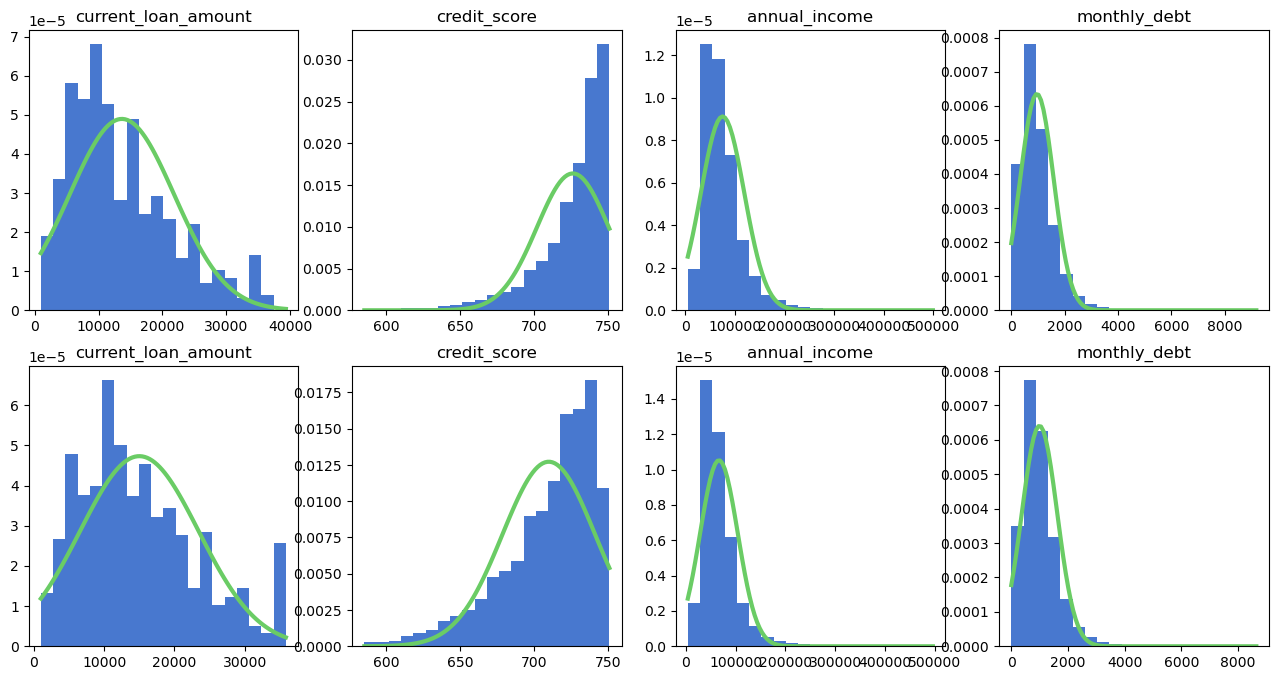

In [89]:
fig, axs = plt.subplots(2, 4, figsize=(16, 8))

# Columns to plot
cols = ["current_loan_amount", "credit_score", "annual_income", "monthly_debt"]

# In the top row, plot the distributions where loan_status == 0
# In the bottom row, plot the distributions where loan_status == 1
for k in [0, 1]:
    # Get the subset of the data where loan_status == k
    loans_plt = loans[loans["loan_status"] == k]
    for i, ax in enumerate(axs[k, :]):
        # Compute the empirical mean and standard deviation
        mu = loans_plt[cols[i]].mean()
        sigma = loans_plt[cols[i]].std()
        
        # Plot the data (density histogram)
        ax.hist(loans_plt[cols[i]], bins=20, density=True)
        ax.set_title(cols[i])

        # Plot a Gaussian distribution with empirical mean and standard deviation
        x = np.linspace(loans_plt[cols[i]].min(), loans_plt[cols[i]].max(), 100)
        ax.plot(x, 1 / (sigma * np.sqrt(2 * np.pi)) * np.exp(- (x - mu)**2 / (2 * sigma**2)),
                lw=3)

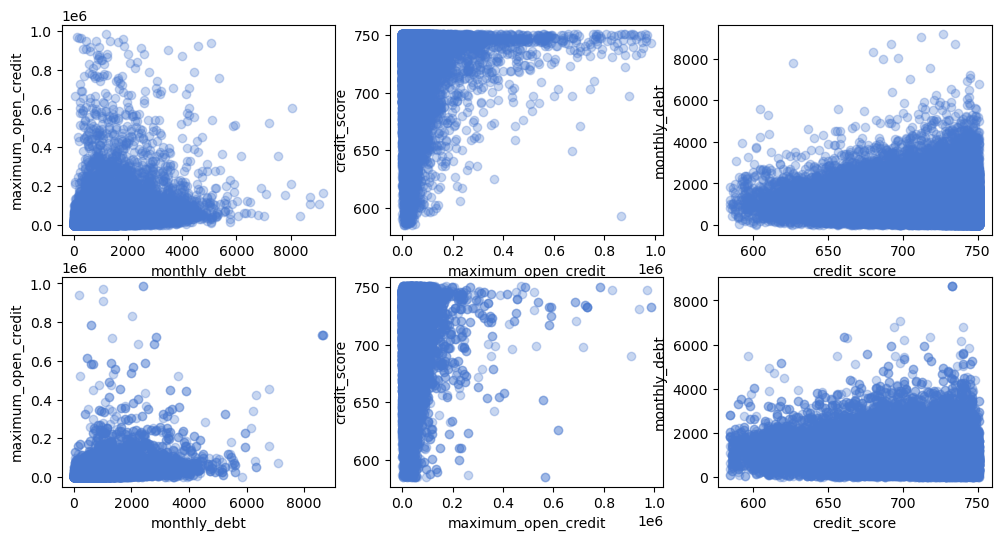

In [90]:
fig, axs = plt.subplots(2, 3, figsize=(12, 6))

# Columns to plot
cols = ["monthly_debt", "maximum_open_credit", "credit_score"]


# In the top row, plot the distributions where loan_status == 0
# In the bottom row, plot the distributions where loan_status == 1
# NOTE: There is no need to understand the details of how the plots are arranged in rows and columns.
for k in [0, 1]:
    # Get the subset of the data where loan_status == k
    loans_plt = loans[loans["loan_status"] == k]
    for i, ax in enumerate(axs[k, :]):
        ax.scatter(loans_plt[cols[i]], loans_plt[cols[(i + 1) % 3]], alpha=0.3)
        ax.set_xlabel(cols[i])
        ax.set_ylabel(cols[(i + 1) % 3])

Now we want to proceed to estimate a Naïve Bayes model. We turn to our standard machine learning library, i.e. Scikit-learn. Btw, you may have wondered why this library is called **Scikit-learn** while we import from **sklearn**. The library’s full name is Scikit-learn, short for *“SciPy Toolkit for Machine Learning.”* It’s part of the broader *SciPy ecosystem*, which includes other toolkits like *Scikit-image* and *Scikit-bio*. When it was developed, the naming convention followed that “scikit” pattern to signal it was a SciPy-compatible extension.

However, in Python, the package name you import is `sklearn`, not `scikit-learn`. That’s just how the developers packaged it — `sklearn` is the technical module name inside the Python ecosystem, while *Scikit-learn* is the project’s official name. 


In [91]:
# Import Gaussian Naïve Bayes algorithm
from sklearn.naive_bayes import GaussianNB

# Import train_test_split
from sklearn.model_selection import train_test_split

In [92]:
# Prepare features and target
X, y = loans.drop(columns=["loan_status"]), loans["loan_status"]

# Split the data into train and test sets so we can evaluate and compare our models
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, 
                                            shuffle=True, random_state=72)

In [93]:
# Create and fit the Gaussian Naïve Bayes classifier
nbc = GaussianNB()

# Fit the model
nbc.fit(X_train, y_train)

GaussianNB()

In [94]:
# Compute the number of correct predictions (accuracy) 
# on the training and test sets
print("Train accuracy:", nbc.score(X_train, y_train))
print("Test accuracy:", nbc.score(X_test, y_test))

Train accuracy: 0.662120272783633
Test accuracy: 0.6635835616438356


Note how we got to the accuracy measures in a very lazy way using the `score()` function. When `score()` is called on a fitted classifier, it calculates the model’s accuracy on the given data. 

We may not have accuracy in class yet. Can you imagine what it measures? If not, Google it.

#### ➡️ ✏️ Task 3

Based on the accuracy, can you assess whether Naïve Bayes is performing well for the credit default prediction task? Let us compare it to another, even more naïve classifier: one that always predicts the most common class.

+ Compute the accuracy of the most common class classifier. For this, go through the following steps:
    1. Check which class is the most common one.
    2. Compute the accuracy if your predictions where always the most common class.
    3. Compare the accuracy of the Naïve Bayes Classifier to the accuracy of the most common class classifier on both train and test sets. What is your conclusion?

*Hint*: You can use the [`accuracy_score`](https://scikit-learn.org/stable/modules/model_evaluation.html#accuracy-score) from `scikit-learn` or also implement it yourself (it is straightforward, we already coded a very similar measure in the `101_ml-intro.ipynb` notebook).

NOTE: In contrast to `score()`, the `accuracy_score()` function provides a more explicit and flexible way to measure accuracy. You supply it with the true labels and the model’s predictions, and it directly computes how many predictions were correct. This approach is clearer, more transparent, and works even when the predictions don’t come from a scikit-learn model.


In [95]:
from sklearn.metrics import accuracy_score

In [96]:
# ➡️ ✏️ Your code here

In [97]:
# SOLUTION
# What is the most common class?
display(  round( y_train.value_counts()/loans.shape[0], 3   ))

# So we predict always zero for the "most-common" classifier
y_pred_train_mc = np.zeros(len(y_train))
y_pred_test_mc = np.zeros(len(y_test))

y_pred_train_nbc = nbc.predict(X_train)
y_pred_test_nbc = nbc.predict(X_test)

print("Train accuracy of most common:", accuracy_score(y_train, y_pred_train_mc))
print("Test accuracy of most common:", accuracy_score(y_test, y_pred_test_mc))
print("Train accuracy of Naïve Bayes:", accuracy_score(y_train, y_pred_train_nbc))
print("Test accuracy of Naïve Bayes:", accuracy_score(y_test, y_pred_test_nbc))

loan_status
0    0.436
1    0.264
Name: count, dtype: float64

Train accuracy of most common: 0.6229592891093201
Test accuracy of most common: 0.6201205479452054
Train accuracy of Naïve Bayes: 0.662120272783633
Test accuracy of Naïve Bayes: 0.6635835616438356


### Logistic Regression Classifier

Similar to how we defined the problem for Naïve Bayes, we have an observation $\mathbf{x}^{(i)}$ and aim to predict the label $y^{(i)} \in \mathcal{Y}$, where $\mathcal{Y} = \mathcal{C} = \{c_1, c_2, \dots, c_k\}$. However, for simplicity, let's focus on the binary classification case where $\mathcal{C} = \{0, 1\}$.

Unlike Naïve Bayes, **the Logistic Regression Classifier does not model the joint probability of features and labels. Instead, it models the conditional probability directly using the logistic function**. In other words, it is **not a generative model** but a **discriminative** one.

$$
\begin{align*}
    P(Y = 1 | X=\mathbf{x}^{(i)}) = \frac{e^{\beta_0 + \beta_1 x_1^{(i)} + \dots + \beta_p x_p^{(i)}}}{1 + e^{\beta_0 + \beta_1 x_1^{(i)} + \dots + \beta_p x_p^{(i)}}}
\end{align*}
$$

Here, $\beta_0, \beta_1, \dots, \beta_p$ are parameters of the model, which we estimate from the data. The classification decision can then be defined as:

$$
\begin{align*}
    f_\text{LR}(\mathbf{x}^{(i)})  &= \underset{c \in \{0,1\}}{\arg\max} \ P(Y =c | X=\mathbf{x}^{(i)}) \\
    &= \begin{cases}
    1 & \text{if } P(Y= 1 | X=\mathbf{x}^{(i)}) > 0.5,\\
    0 & \text{otherwise}.
    \end{cases}
\end{align*}
$$

In practice, Logistic Regression is used for binary classification, and extensions like Multinomial Logistic Regression (also called Softmax Regression) are used for multi-class problems.

For model training, we maximize the likelihood function, which is equivalent to minimizing the logistic loss (or cross-entropy loss) over all observations:

$$
\begin{align*}
    \mathcal{L}(\beta) &= \sum_{i=1}^N y^{(i)} \log(P(Y=1|X=\mathbf{x}^{(i)})) + (1-y^{(i)}) \log(1 - P(Y=1|X=\mathbf{x}^{(i)})) \\
    &= \sum_{i=1}^N y^{(i)} \log\left(\frac{e^{\beta_0 + \beta_1 x_1^{(i)} + \dots + \beta_p x_p^{(i)}}}{1 + e^{\beta_0 + \beta_1 x_1^{(i)} + \dots + \beta_p x_p^{(i)}}}\right) + (1-y^{(i)}) \log\left(\frac{1}{1 + e^{\beta_0 + \beta_1 x_1^{(i)} + \dots + \beta_p x_p^{(i)}}}\right).
\end{align*}
$$

#### ➡️ ✏️ Task 4

Repeat the structure implemented above the Naïve Bayes Classifier for the Logistic Regression. Compare the accuracy of the Logistic Regression to the accuracy of the Naïve Bayes Classifier on both train and test sets.

*HINT*: You can increase the number of iterations using ` LogisticRegression(max_iter=...)`. You may want to try this out depending on warnings that you may get after fitting the logistic regression. Don't go too high to quickly, otherwise, the estimation will run for a long time. Does this remind you of any other notebook from this course?

In [98]:
from sklearn.linear_model import LogisticRegression

In [99]:
# ➡️ ✏️ Your code here

In [100]:
# SOLUTION

lrc = LogisticRegression(penalty = 'l2',max_iter=1000)  # Evem fpr 10000 there is convergence failure
lrc.fit(X_train, y_train)

y_pred_train_lrc = lrc.predict(X_train)
y_pred_test_lrc = lrc.predict(X_test)


print("Train accuracy of most common:", accuracy_score(y_train, y_pred_train_mc))
print("Test accuracy of most common:", accuracy_score(y_test, y_pred_test_mc))
print("Train accuracy of Naïve Bayes:", accuracy_score(y_train, y_pred_train_nbc))
print("Test accuracy of Naïve Bayes:", accuracy_score(y_test, y_pred_test_nbc))
print("Train accuracy of Logistic Reg.:", accuracy_score(y_train, y_pred_train_lrc))
print("Test accuracy of Logistic Reg.:", accuracy_score(y_test, y_pred_test_lrc))

Train accuracy of most common: 0.6229592891093201
Test accuracy of most common: 0.6201205479452054
Train accuracy of Naïve Bayes: 0.662120272783633
Test accuracy of Naïve Bayes: 0.6635835616438356
Train accuracy of Logistic Reg.: 0.6538353153356253
Test accuracy of Logistic Reg.: 0.6547506849315069


/opt/conda/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


#### ➡️ ✏️ Task 5 (Optional, if you have time)

Consider the below code that applies a feature transformation using a "pipeline". Run it and try to understand what is going on. Does it help for convergence? Does it help for better predictive performance? 

In [101]:
from sklearn.preprocessing import PowerTransformer, StandardScaler
from sklearn.pipeline import Pipeline

In [102]:
nbc = Pipeline([
    ("feature_transform", PowerTransformer()),
    ("classifier", GaussianNB())
])

lrc = Pipeline([
    ("feature_transform", PowerTransformer()),
    ("classifier", LogisticRegression(penalty = 'l2'))
])

In [103]:
nbc.fit(X_train, y_train)
lrc.fit(X_train, y_train)

y_pred_train_nbc = nbc.predict(X_train)
y_pred_train_lrc = lrc.predict(X_train)
y_pred_test_nbc = nbc.predict(X_test)
y_pred_test_lrc = lrc.predict(X_test)

In [104]:
print("Train accuracy of most common:", accuracy_score(y_train, y_pred_train_mc))
print("Test accuracy of most common:", accuracy_score(y_test, y_pred_test_mc))
print("Train accuracy of Naïve Bayes:", accuracy_score(y_train, y_pred_train_nbc))
print("Test accuracy of Naïve Bayes:", accuracy_score(y_test, y_pred_test_nbc))
print("Train accuracy of Logistic Reg.:", accuracy_score(y_train, y_pred_train_lrc))
print("Test accuracy of Logistic Reg.:", accuracy_score(y_test, y_pred_test_lrc))

Train accuracy of most common: 0.6229592891093201
Test accuracy of most common: 0.6201205479452054
Train accuracy of Naïve Bayes: 0.6502470457833136
Test accuracy of Naïve Bayes: 0.6520986301369863
Train accuracy of Logistic Reg.: 0.6745477089556445
Test accuracy of Logistic Reg.: 0.6759232876712329


**Why does logit converge now?**

Because we transformed the data, leading to a more similar scale of all variables.
This has two effects:
- `LogisticRegression` by default uses a ridge (`l2`) penalty. From the regularization notebooks, we remember that input features need to be standardized (because there is only one $\lambda$ for all features).
- For numeric optimization problems such as logit, the scale of variables matter: the optimizer to find the extremum has a much harder time when features are on very different scales. (This is similar to what we observed in gradient descent.) This optimization difficulty exists also for non-regularized logit. 


#### ➡️ ✏️ Task 6 (Optional, if you have spare time)

Reading the discussion on handling missing data above, think of how you could apply this to the current dataset and observe whether you can improve your models in doing so.


In [105]:
# ➡️ ✏️ Your code here